Hands on Lab:
    1-Load and clean a provided dataset with Pandas (handling any missing values).
    2-Use NumPy to compute at least one derived numeric feature or summary statistic.
    3-Produce at least three labeled plots (including a histogram and a scatter plot) exploring the data.
    4-Write Markdown cells explaining what each visualization reveals about the data.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Task 1:

In [3]:
df = pd.read_csv("data.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     str    
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.4 KB


at first lets check how many null values we got: (3)

In [6]:
df.isnull().sum

<bound method DataFrame.sum of     Duration   Date  Pulse  Maxpulse  Calories
0      False  False  False     False     False
1      False  False  False     False     False
2      False  False  False     False     False
3      False  False  False     False     False
4      False  False  False     False     False
5      False  False  False     False     False
6      False  False  False     False     False
7      False  False  False     False     False
8      False  False  False     False     False
9      False  False  False     False     False
10     False  False  False     False     False
11     False  False  False     False     False
12     False  False  False     False     False
13     False  False  False     False     False
14     False  False  False     False     False
15     False  False  False     False     False
16     False  False  False     False     False
17     False  False  False     False     False
19     False  False  False     False     False
20     False  False  False   

since we only have 3 values, cleaning the null rows by droping them shouldn't affect data integrity.

In [57]:
df.dropna(inplace=True) # drop the null rows 

Then fill in empty spaces with mean.
It also has an outlier value of 450 for duration which ill consider as a typo.
We also drop duplicates.

In [64]:
df['Calories'] = df['Calories'].fillna(df['Calories'].mean())
df.loc[df['Duration'] == 450, 'Duration'] = 45 # for rows with duration as 450 turn it into 45
df.drop_duplicates(inplace=True)

Task 2:

Calculating calaories per minute using np divide then adding it as a new column:

In [69]:
df['Cal_Per_Min'] = np.round(np.divide(df['Calories'], df['Duration']), 2)

print("Summary Statistics for Cal_Per_Min:")
print(df['Cal_Per_Min'].describe())

Summary Statistics for Cal_Per_Min:
count    28.000000
mean      5.524286
std       1.202376
min       3.590000
25%       4.647500
50%       5.480000
75%       6.242500
max       9.020000
Name: Cal_Per_Min, dtype: float64


Task 3:

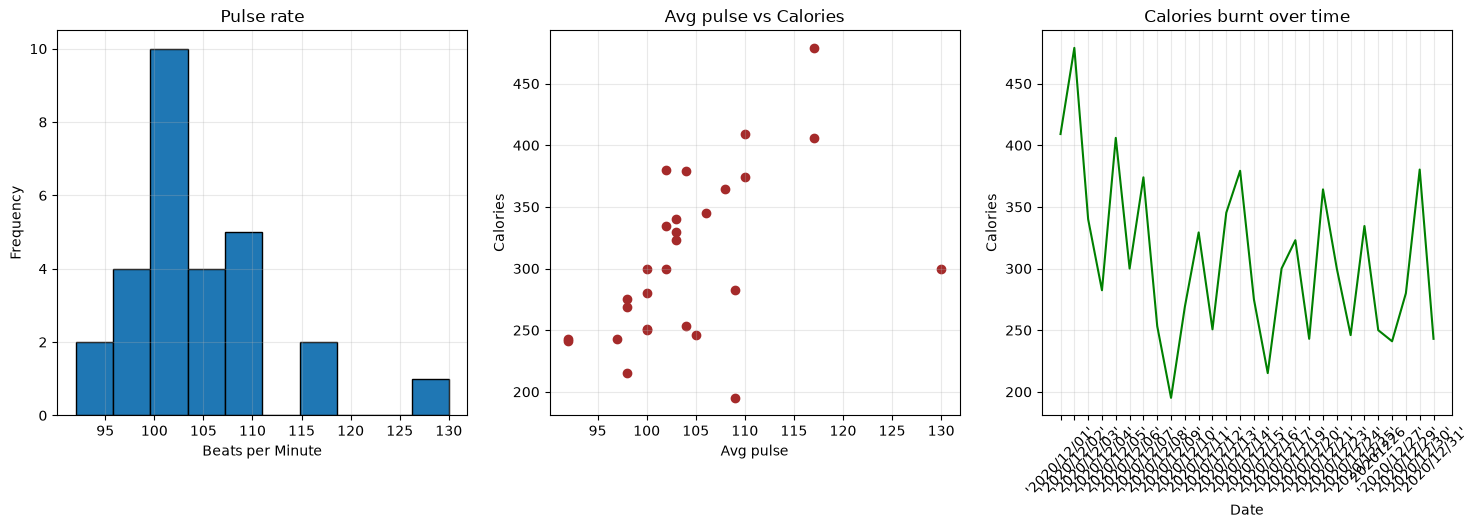

In [95]:
fig , axes = plt.subplots(1,3, figsize = (18,5))

#plot 1 histogram (pulse rate)
axes[0].set_title("Pulse rate")
axes[0].hist(df['Pulse'],edgecolor='black')
axes[0].set_xlabel('Beats per Minute')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha = .27)

#plot 2 scatter plot
axes[1].set_title("Avg pulse vs Calories")
axes[1].scatter(df['Pulse'],df['Calories'],color ='brown')
axes[1].set_xlabel('Avg pulse')
axes[1].set_ylabel('Calories')
axes[1].grid(True, alpha = .27)

axes[2].set_title("Calories burnt over time")
axes[2].plot(df['Date'],df['Calories'],color ='green')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Calories')
axes[2].grid(True, alpha = .27)
axes[2].tick_params(axis='x', rotation=45) # Rotates dates so they don't overlap



plt.show()

Task 4:

Analysis of the visuals:
1- histogram: (pulse rate)
    it demonstrates that the Avg pulse during these workouts most frequently lies around 95-110 BPM.
2- scatter plot: (Avg pulse vs Calories)
    there apperes to be some moderate corelation between Avg pulse and calories burned, days with slightly higher pulse appear to have higher amount of burned calories.
3- line plot: (Calories burned over time)
    it tracks daily workout performance during the month of december. it is generally showing relativly stable results between 250-400 calories burned.

--Ignore the follwing part, as it was used to practice.--

one histogram (Calories) and a scattered plot representing (pulse vs calories)

Text(0, 0.5, 'pulse')

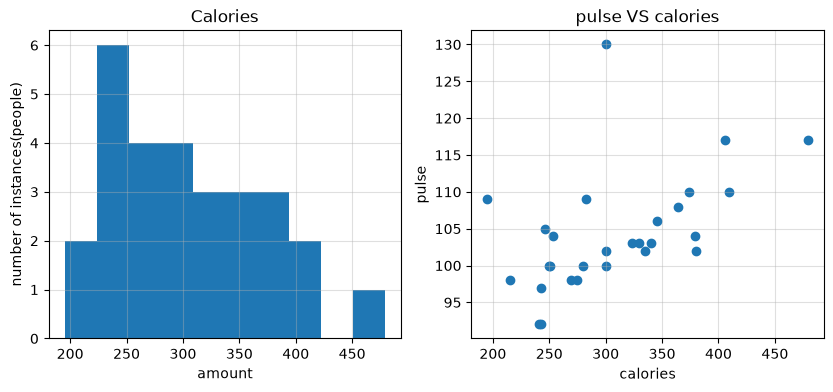

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].set_title('Calories')
axes[0].hist(df['Calories'])
axes[0].grid(True, alpha= .4)
axes[0].set_xlabel('amount')
axes[0].set_ylabel('number of instances(people)')

axes[1].set_title('pulse VS calories')
axes[1].scatter(df['Calories'], df['Pulse'])
axes[1].grid(True, alpha= .4)
axes[1].set_xlabel('calories')
axes[1].set_ylabel('pulse')

Two seperate line graphs :(calories - duration)

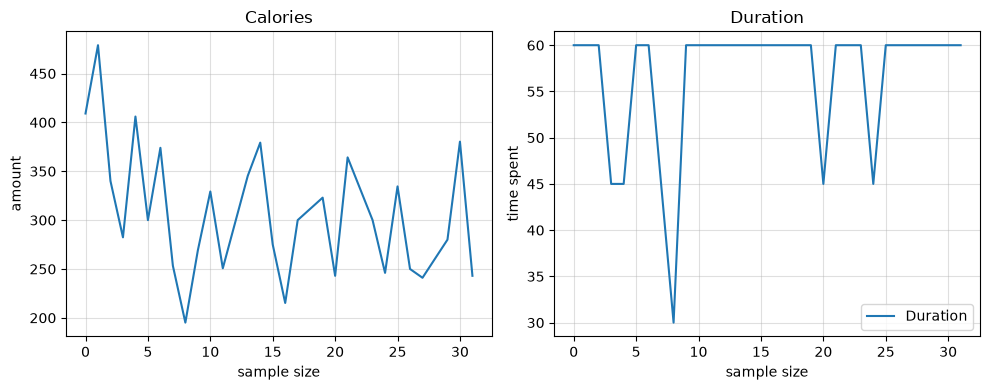

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].set_title('Calories')
axes[0].plot(df['Calories'],label = 'Calories')
axes[0].grid(True, alpha= .4)
axes[0].set_xlabel('sample size')
axes[0].set_ylabel('amount')


#axes[1].scatter(df["Calories"], df["Maxpulse"])

axes[1].set_title('Duration')
axes[1].plot(df['Duration'],label = 'Duration')
axes[1].grid(True, alpha= .4)
axes[1].set_xlabel('sample size')
axes[1].set_ylabel('time spent')
plt.legend()
plt.tight_layout()
